<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment_15:Loan prediction

**objective:**

Analyzing business problems, preprocess data, build machine learning models, and evaluate them for performance and fairness.

**Data source:**

 provided in class

**Problem Statement:**

A financial institution wants to predict which borrowers are likely to default on their loans


Importing necessary libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Loading the data set**

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Data_set/bank-loan.csv')
df.head(2)

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0


In [5]:
df.shape

(850, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


In [6]:
df.isnull().sum()

,0
age,0
ed,0
employ,0
address,0
income,0
debtinc,0
creddebt,0
othdebt,0
default,150


If the target variable contains missing values, it is generally difficult to impute them because the target depends on the relationships among all the features. Filling missing target values using methods such as the mean, median, or prediction can introduce bias. Therefore, removed the rows with missing target values.

In [8]:
df.dropna(subset=['default'], inplace=True)

In [9]:
# checking the missing values
df.isnull().sum()

,0
age,0
ed,0
employ,0
address,0
income,0
debtinc,0
creddebt,0
othdebt,0
default,0


**Visualize the Target Distribution**

This chart helps us quickly see whether the dataset is balanced or imbalanced. If one class is much more frequent than the other, accuracy alone may be misleading.

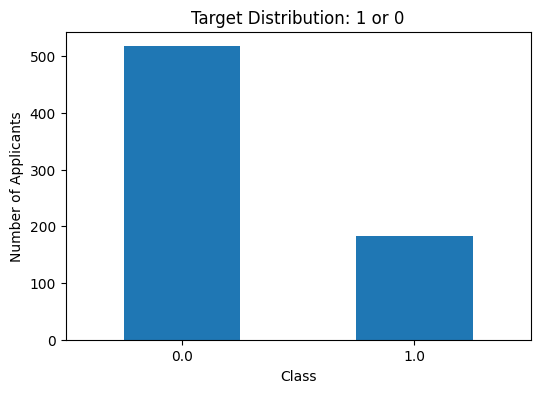

In [10]:
plt.figure(figsize=(6, 4))
df['default'].value_counts().plot(kind='bar')
plt.title('Target Distribution: 1 or 0')
plt.xlabel('Class')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.show()

The target variable is imbalanced, with Class 0 occurring much more frequently than Class 1. In such cases, accuracy alone can be misleading because a model can achieve high accuracy simply by predicting the majority class most of the time while failing to correctly identify the minority class. Therefore, model performance should also be evaluated using precision, recall, F1-score, and the confusion matrix, which provide a more comprehensive assessment of how well the model predicts both classes

**Visualize distributions and relationships between features.**

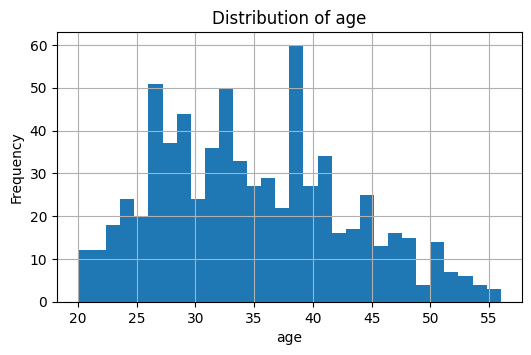

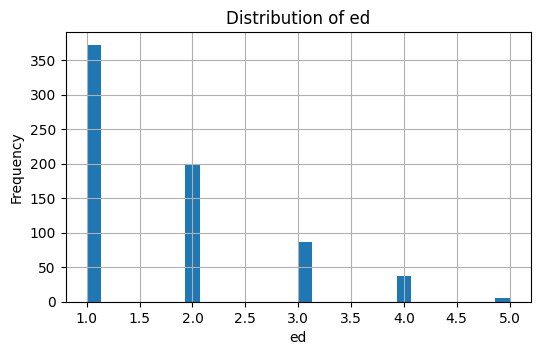

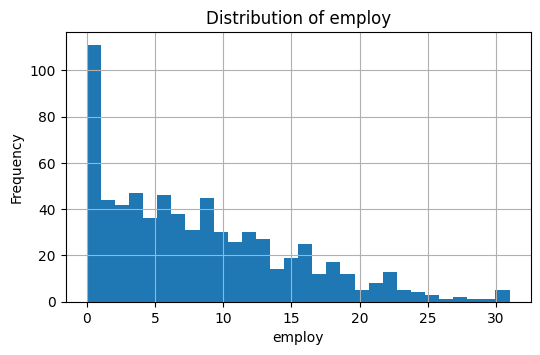

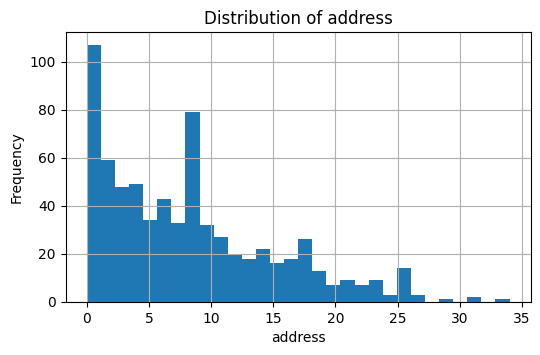

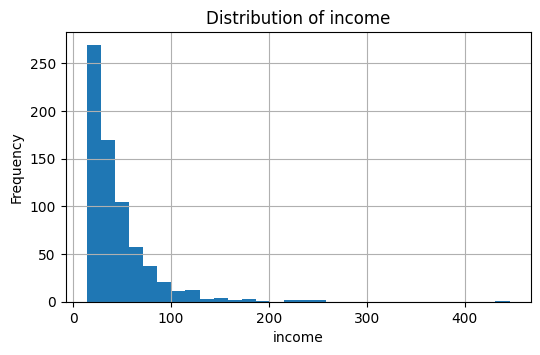

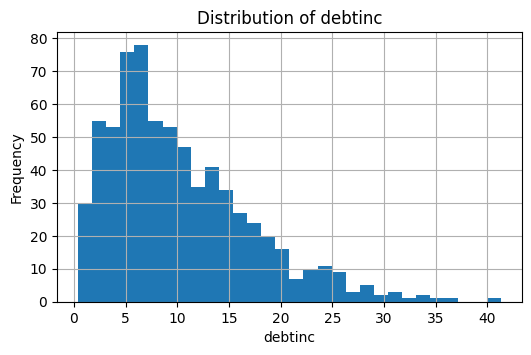

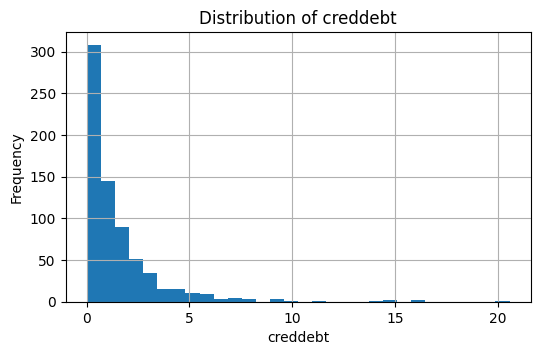

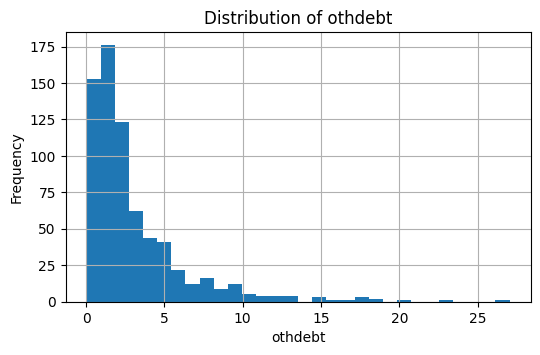

In [11]:
TARGET='default'
numerical_features = df.drop(columns=[TARGET]).select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numerical_features:
    plt.figure(figsize=(6, 3.5))
    df[col].hist(bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

**Feature Engineering**

Feature engineering requires domain knowledge to create meaningful features that capture important relationships within the data.
from my general knowledge I believe those two features are important.

TotalDebt captures the customer's overall financial obligation.

IncomePerDebt measures repayment capacity.

In [13]:
df["TotalDebt"] = df["creddebt"] + df["othdebt"]
df["IncomePerDebt"] = df["income"] / (df["TotalDebt"] + 1)


In [15]:
df.head(2)

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,TotalDebt,IncomePerDebt
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0,16.368,10.133579
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0,5.363,4.871916


**Model Building and Evaluation**

Split features and target

In [16]:
X = df.drop(columns=['default'])
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

**Model**

I choose LogisticRegression since the predict value is binary

I standarlized features after the data is splitted to avoid data leakage


In [17]:
lr_model = Pipeline([ ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))])

lr_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='accuracy')
print("Logistic Regression CV Scores:", lr_scores)
print("Mean CV Accuracy:", lr_scores.mean())

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("Classification Report:\n", classification_report(y_test,y_pred))

Logistic Regression CV Scores: [0.8125     0.8125     0.8125     0.76785714 0.8125    ]
Mean CV Accuracy: 0.8035714285714285
Accuracy: 0.8142857142857143
Confusion Matrix:
 [[91 12]
 [14 23]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.88      0.88       103
         1.0       0.66      0.62      0.64        37

    accuracy                           0.81       140
   macro avg       0.76      0.75      0.76       140
weighted avg       0.81      0.81      0.81       140



The model performs well in identifying customers who are unlikely to default (Class 0) with Precision of 0.87, but it is less effective at detecting actual defaulters (Class 1) about Precision of 0.66.

**Analyze feature importance **

determining which factors impact loan defaults

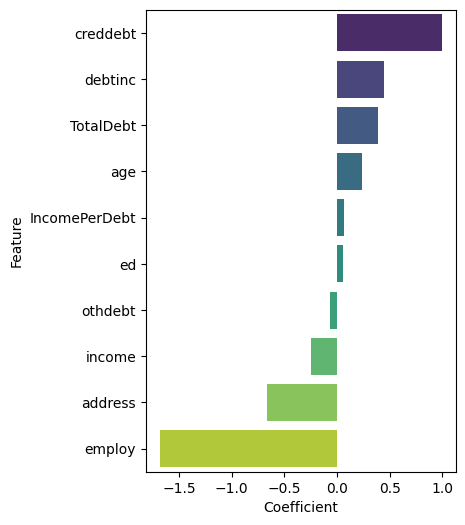

In [20]:
importance = pd.DataFrame({'Feature': X.columns,
                           'Coefficient': lr_model.named_steps['model'].coef_[0]}).sort_values(by='Coefficient', ascending=False)
plt.figure(figsize=(4,6))
sns.barplot(data=importance, x='Coefficient', y='Feature', hue='Feature',
            palette='viridis', legend=False, dodge=False)
plt.show()

The model suggests that debt-related features (credit debt, debt-to-income ratio, and total debt) are the strongest factors increasing default risk, while financial stability indicators such as employment duration, income, and residential stability help reduce the likelihood of default.

**Explainability and Fairness Analysis**

In [27]:
from fairlearn.metrics import selection_rate, true_positive_rate, false_positive_rate, count, MetricFrame
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

A_test = pd.cut(X_test['age'], bins=age_bins, labels=age_labels, right=False)

metrics_dict = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate,
    'true_positive_rate': true_positive_rate,
    'false_positive_rate': false_positive_rate,
    'count': count,
}

mf = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print('\nOverall metrics')
print(mf.overall)
print('\nMetrics grouped by age group')
print(mf.by_group)


Overall metrics
accuracy                 0.814286
selection_rate           0.250000
true_positive_rate       0.621622
false_positive_rate      0.116505
count                  140.000000
dtype: float64

Metrics grouped by age group
       accuracy  selection_rate  true_positive_rate  false_positive_rate  \
age                                                                        
25-34  0.805970        0.253731            0.600000             0.106383   
35-44  0.833333        0.208333            0.625000             0.125000   
45-54  0.882353        0.235294            0.666667             0.000000   
<25    0.625000        0.500000            0.666667             0.400000   

       count  
age           
25-34   67.0  
35-44   48.0  
45-54   17.0  
<25      8.0  


The results suggest that the model may perform less fairly for younger customers, especially those under 25. The higher false positive rate means some younger applicants may be incorrectly classified as higher-risk, which could negatively affect their access to credit

In [29]:
import shap
RANDOM_STATE = 42
scaler = lr_model.named_steps['scaler']
clf    = lr_model.named_steps['model']

X_test_scaled  = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)


background = shap.sample(X_train_scaled, 200, random_state=RANDOM_STATE)

print('Computing SHAP values (KernelExplainer — may take ~1 minute)...')
explainer_shap = shap.KernelExplainer(clf.predict_proba, background)

shap_values = explainer_shap.shap_values(
    X_test_scaled[:300], nsamples=100
)
print('SHAP values computed.')

Computing SHAP values (KernelExplainer — may take ~1 minute)...


  0%|          | 0/140 [00:00<?, ?it/s]

SHAP values computed.


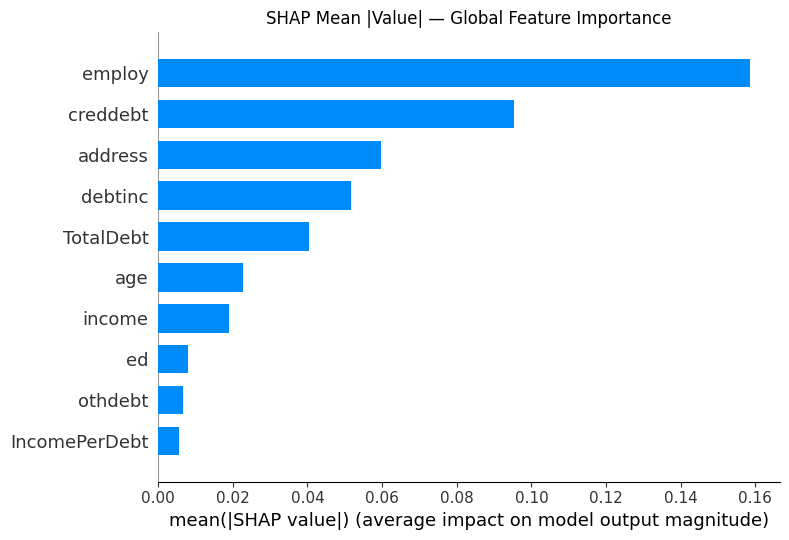

In [31]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
FEATURE_COLS = X_test.columns

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled_df,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('SHAP Mean |Value| — Global Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

**Ethical Considerations**

The model was evaluated across age groups to identify possible differences in prediction performance. Since loan decisions can affect people's financial opportunities, fairness monitoring is necessary to prevent unfair treatment and Model explainability was improved using SHAP and coefficient analysis. This allows stakeholders to understand why certain predictions were made.